# Factor Analysis

This notebook analyzes factor-related metrics from the research study comparing Baseline tools vs Narrative Scaffolding (NS) conditions:
- **factors_explored**: Number of factors participants explored during the task
- **factors_used_in_decision**: Number of factors participants used in their final decision

In [29]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

In [30]:
# Load and examine participant log summary data
try:
    participant_summary = pd.read_csv('participants_log_summary.csv')
    print("=== PARTICIPANT LOG SUMMARY LOADED ===")
    print(f"Shape: {participant_summary.shape}")
    print(f"Columns: {list(participant_summary.columns)}")
    print(f"\nFirst few rows:")
    print(participant_summary.head())
    
    # Check for factor-related columns
    print(f"\n=== FACTOR-RELATED COLUMNS ===")
    factor_cols = [col for col in participant_summary.columns if 'factor' in col.lower()]
    print(f"Factor-related columns: {factor_cols}")
    
    # Display unique values in condition column
    print(f"\nUnique values in 'condition': {participant_summary['condition'].unique()}")
    
except FileNotFoundError:
    print("Error: participants_log_summary.csv not found in current directory")
except Exception as e:
    print(f"Error loading file: {e}")

=== PARTICIPANT LOG SUMMARY LOADED ===
Shape: (40, 13)
Columns: ['participant_id', 'condition', 'final_time', 'insights_generated', 'factors_explored', 'factors_included_in_story', 'factors_used_in_decision', 'branches_created', 'divergence_semantic_distance_avg', 'divergence_semantic_distance_min', 'divergence_semantic_distance_max', 'reflection_events', 'reflection_edit_coupled']

First few rows:
             participant_id condition  final_time  insights_generated  \
0  597fe89a1b41a20001749f57  Baseline       29.45                   7   
1  597fe89a1b41a20001749f57        NS       31.12                  10   
2  5f4520ebb012170878012efc  Baseline       30.89                   8   
3  5f4520ebb012170878012efc        NS       32.34                  11   
4  607668ac450fc6e3025a131d  Baseline       28.77                   7   

   factors_explored  factors_included_in_story  factors_used_in_decision  \
0                 5                        NaN                         2   
1      

In [31]:
# Analyze factor metrics by condition
def analyze_factor_metrics(data):
    """
    Analyze factors_explored and factors_used_in_decision by condition
    """
    
    # Separate by condition
    baseline_data = data[data['condition'] == 'Baseline'].copy()
    ns_data = data[data['condition'] == 'NS'].copy()
    
    print("=== FACTOR METRICS ANALYSIS ===")
    print("=" * 50)
    
    print(f"Sample sizes:")
    print(f"  Baseline: {len(baseline_data)} participants")
    print(f"  NS: {len(ns_data)} participants")
    
    # Metrics to analyze
    metrics = ['factors_explored', 'factors_used_in_decision']
    
    results = {}
    
    for metric in metrics:
        print(f"\n{'='*60}")
        print(f"ANALYSIS: {metric.upper().replace('_', ' ')}")
        print(f"{'='*60}")
        
        # Get data for this metric
        baseline_values = baseline_data[metric].dropna()
        ns_values = ns_data[metric].dropna()
        
        # Basic statistics
        baseline_stats = {
            'count': len(baseline_values),
            'mean': baseline_values.mean(),
            'std': baseline_values.std(),
            'median': baseline_values.median(),
            'min': baseline_values.min(),
            'max': baseline_values.max(),
            'sum': baseline_values.sum()
        }
        
        ns_stats = {
            'count': len(ns_values),
            'mean': ns_values.mean(),
            'std': ns_values.std(),
            'median': ns_values.median(),
            'min': ns_values.min(),
            'max': ns_values.max(),
            'sum': ns_values.sum()
        }
        
        print(f"\nBASELINE STATISTICS:")
        print(f"  Count: {baseline_stats['count']}")
        print(f"  Mean: {baseline_stats['mean']:.2f}")
        print(f"  Std: {baseline_stats['std']:.2f}")
        print(f"  Median: {baseline_stats['median']:.2f}")
        print(f"  Range: {baseline_stats['min']:.0f} - {baseline_stats['max']:.0f}")
        print(f"  Total: {baseline_stats['sum']:.0f}")
        
        print(f"\nNarrative Scaffolding STATISTICS:")
        print(f"  Count: {ns_stats['count']}")
        print(f"  Mean: {ns_stats['mean']:.2f}")
        print(f"  Std: {ns_stats['std']:.2f}")
        print(f"  Median: {ns_stats['median']:.2f}")
        print(f"  Range: {ns_stats['min']:.0f} - {ns_stats['max']:.0f}")
        print(f"  Total: {ns_stats['sum']:.0f}")
        
        # Calculate ratios and differences
        mean_ratio = ns_stats['mean'] / baseline_stats['mean'] if baseline_stats['mean'] > 0 else float('inf')
        mean_difference = ns_stats['mean'] - baseline_stats['mean']
        total_ratio = ns_stats['sum'] / baseline_stats['sum'] if baseline_stats['sum'] > 0 else float('inf')
        
        print(f"\nCOMPARATIVE ANALYSIS:")
        print(f"  Mean Ratio (NS/Baseline): {mean_ratio:.2f}x")
        print(f"  Mean Difference (NS - Baseline): {mean_difference:+.2f}")
        print(f"  Total Ratio (NS/Baseline): {total_ratio:.2f}x")
        print(f"  Percentage Change: {((mean_ratio - 1) * 100):+.1f}%")
        
        # Statistical tests
        print(f"\nSTATISTICAL TESTS:")
        
        if len(baseline_values) > 0 and len(ns_values) > 0:
            # Mann-Whitney U test (non-parametric)
            try:
                u_statistic, u_p_value = stats.mannwhitneyu(baseline_values, ns_values, alternative='two-sided')
                print(f"  Mann-Whitney U test:")
                print(f"    Statistic: {u_statistic:.3f}")
                print(f"    p-value: {u_p_value:.6f}")
                print(f"    Significant (α=0.05): {'Yes' if u_p_value < 0.05 else 'No'}")
            except Exception as e:
                print(f"  Mann-Whitney U test: Error - {e}")
            
            # Welch's t-test (assumes unequal variances)
            try:
                t_statistic, t_p_value = stats.ttest_ind(baseline_values, ns_values, equal_var=False)
                print(f"  Welch's t-test:")
                print(f"    Statistic: {t_statistic:.3f}")
                print(f"    p-value: {t_p_value:.6f}")
                print(f"    Significant (α=0.05): {'Yes' if t_p_value < 0.05 else 'No'}")
            except Exception as e:
                print(f"  Welch's t-test: Error - {e}")
            
            # Effect size (Cohen's d)
            try:
                pooled_std = np.sqrt(((len(baseline_values) - 1) * baseline_stats['std']**2 + 
                                    (len(ns_values) - 1) * ns_stats['std']**2) / 
                                   (len(baseline_values) + len(ns_values) - 2))
                if pooled_std > 0:
                    cohens_d = (ns_stats['mean'] - baseline_stats['mean']) / pooled_std
                    print(f"  Effect size (Cohen's d): {cohens_d:.3f}")
                    
                    # Interpret effect size
                    if abs(cohens_d) < 0.2:
                        effect_label = "negligible"
                    elif abs(cohens_d) < 0.5:
                        effect_label = "small"
                    elif abs(cohens_d) < 0.8:
                        effect_label = "medium"
                    else:
                        effect_label = "large"
                    
                    print(f"    Interpretation: {effect_label} effect")
            except Exception as e:
                print(f"  Effect size calculation: Error - {e}")
        
        # Store results
        results[metric] = {
            'baseline': baseline_stats,
            'ns': ns_stats,
            'mean_ratio': mean_ratio,
            'mean_difference': mean_difference,
            'total_ratio': total_ratio,
            'percentage_change': (mean_ratio - 1) * 100,
            'u_p_value': u_p_value if 'u_p_value' in locals() else None,
            't_p_value': t_p_value if 't_p_value' in locals() else None,
            'cohens_d': cohens_d if 'cohens_d' in locals() else None
        }
    
    return results

# Run the analysis
factor_results = analyze_factor_metrics(participant_summary)

=== FACTOR METRICS ANALYSIS ===
Sample sizes:
  Baseline: 20 participants
  NS: 20 participants

ANALYSIS: FACTORS EXPLORED

BASELINE STATISTICS:
  Count: 20
  Mean: 5.30
  Std: 1.38
  Median: 5.00
  Range: 3 - 8
  Total: 106

Narrative Scaffolding STATISTICS:
  Count: 20
  Mean: 7.00
  Std: 0.92
  Median: 7.00
  Range: 5 - 8
  Total: 140

COMPARATIVE ANALYSIS:
  Mean Ratio (NS/Baseline): 1.32x
  Mean Difference (NS - Baseline): +1.70
  Total Ratio (NS/Baseline): 1.32x
  Percentage Change: +32.1%

STATISTICAL TESTS:
  Mann-Whitney U test:
    Statistic: 66.000
    p-value: 0.000228
    Significant (α=0.05): Yes
  Welch's t-test:
    Statistic: -4.587
    p-value: 0.000062
    Significant (α=0.05): Yes
  Effect size (Cohen's d): 1.450
    Interpretation: large effect

ANALYSIS: FACTORS USED IN DECISION

BASELINE STATISTICS:
  Count: 20
  Mean: 2.50
  Std: 0.69
  Median: 2.50
  Range: 1 - 4
  Total: 50

Narrative Scaffolding STATISTICS:
  Count: 20
  Mean: 3.75
  Std: 0.72
  Median: 4.00

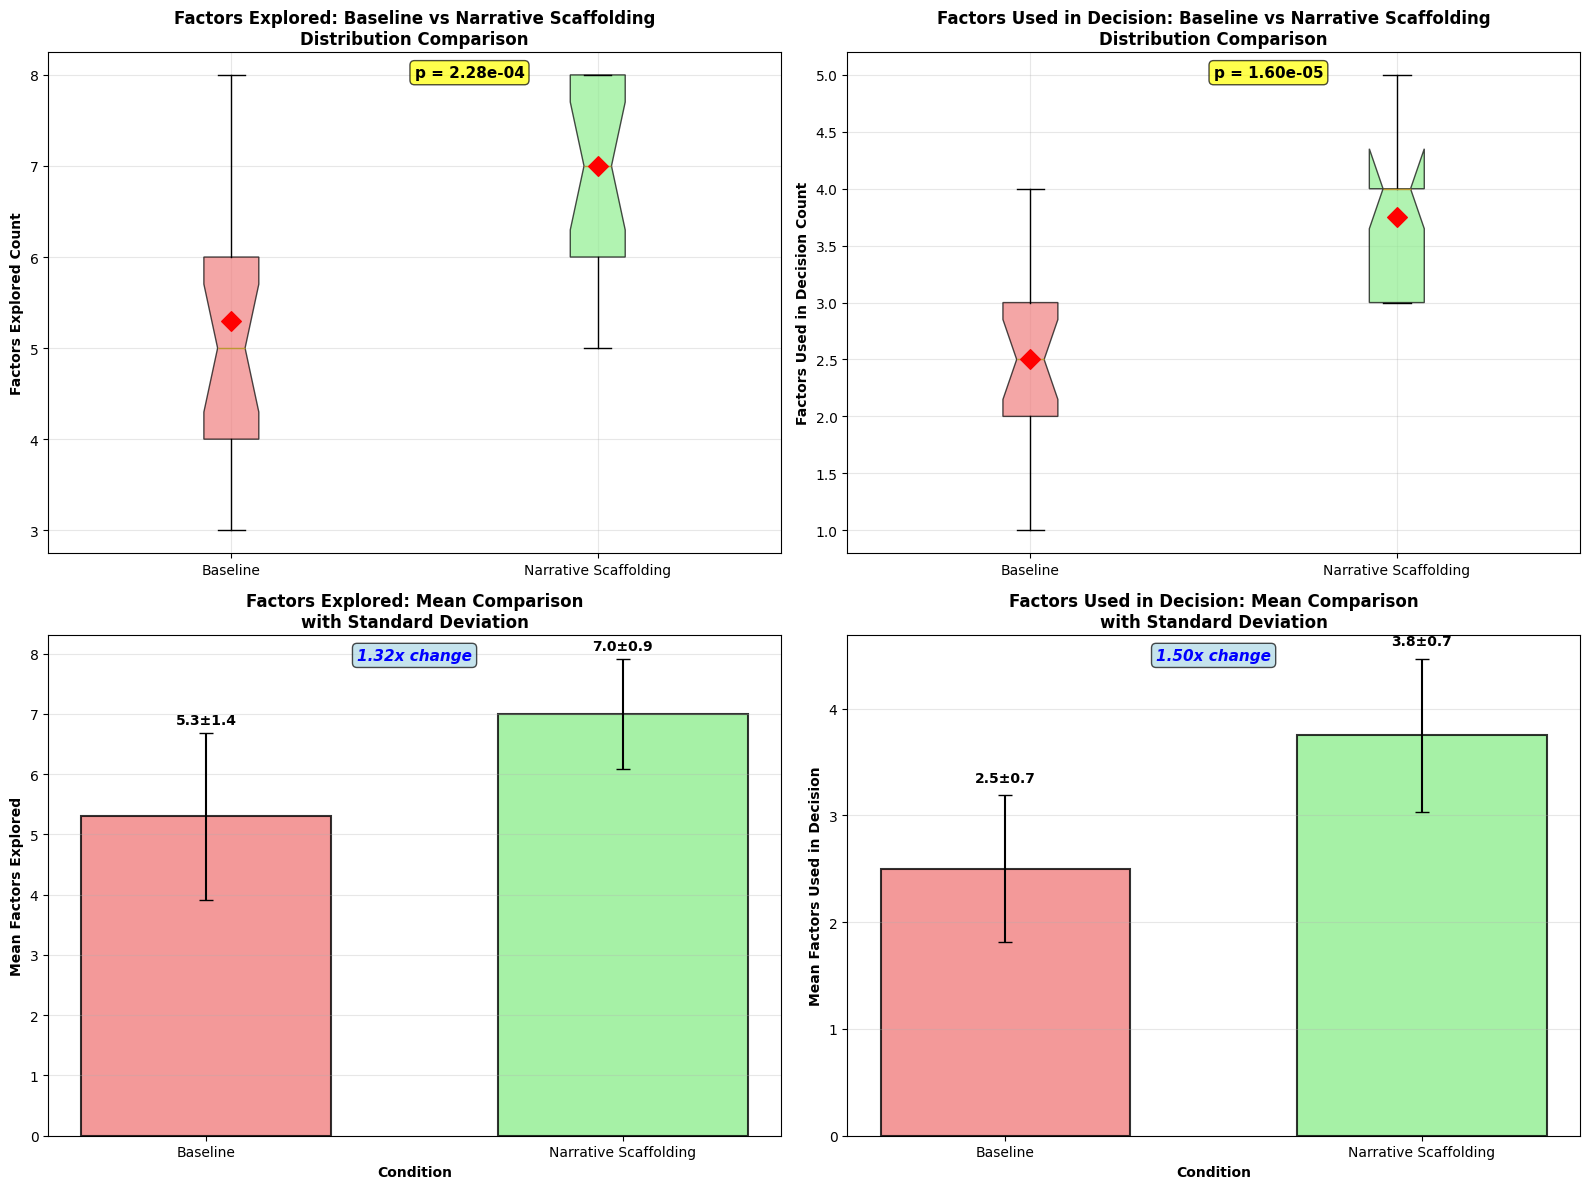


FACTOR METRICS SUMMARY TABLE
Metric                    Baseline        NS              Ratio      p-value      Effect    
--------------------------------------------------------------------------------
Factors Explored          5.3             7.0             1.32       2.28e-04     1.45      
Factors Used in Decision  2.5             3.8             1.50       1.60e-05     1.78      
--------------------------------------------------------------------------------

KEY INSIGHTS:

📊 FACTORS EXPLORED:
   • Baseline: 5.3 ± 1.4
   • NS: 7.0 ± 0.9
   • Change: +32.1% (1.32x)
   • Statistical significance: significant (p = 0.0002)
   • Effect size: large (Cohen's d = 1.45)

📊 FACTORS USED IN DECISION:
   • Baseline: 2.5 ± 0.7
   • NS: 3.8 ± 0.7
   • Change: +50.0% (1.50x)
   • Statistical significance: significant (p = 0.0000)
   • Effect size: large (Cohen's d = 1.78)

🎯 SUMMARY:
   • Factor exploration and decision-making patterns analysis
   • Comparison of baseline vs Narrative Scaffol

In [32]:
# Create visualizations for factor metrics comparison
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Prepare data for visualization
baseline_data = participant_summary[participant_summary['condition'] == 'Baseline']
ns_data = participant_summary[participant_summary['condition'] == 'NS']

metrics = ['factors_explored', 'factors_used_in_decision']
metric_labels = ['Factors Explored', 'Factors Used in Decision']

# Box plots for both metrics
for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = [ax1, ax2][i]
    
    data_for_box = [baseline_data[metric].dropna(), ns_data[metric].dropna()]
    box_plot = ax.boxplot(data_for_box, labels=['Baseline', 'Narrative Scaffolding'], 
                         patch_artist=True, notch=True)
    
    # Color the boxes
    box_plot['boxes'][0].set_facecolor('lightcoral')
    box_plot['boxes'][0].set_alpha(0.7)
    box_plot['boxes'][1].set_facecolor('lightgreen')
    box_plot['boxes'][1].set_alpha(0.7)
    
    ax.set_ylabel(f'{label} Count', fontweight='bold')
    ax.set_title(f'{label}: Baseline vs Narrative Scaffolding\nDistribution Comparison', 
                 fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Add mean markers
    baseline_mean = baseline_data[metric].mean()
    ns_mean = ns_data[metric].mean()
    ax.scatter([1, 2], [baseline_mean, ns_mean], color='red', s=100, marker='D', 
              label='Mean', zorder=5)
    
    # Add statistical annotation
    p_value = factor_results[metric]['u_p_value']
    if p_value is not None:
        ax.text(0.5, 0.95, f'p = {p_value:.2e}' if p_value < 0.001 else f'p = {p_value:.4f}', 
                transform=ax.transAxes, fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# Bar charts for comparison
colors = ['lightcoral', 'lightgreen']
x_pos = [0, 1]
width = 0.6

for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = [ax3, ax4][i]
    
    baseline_mean = baseline_data[metric].mean()
    ns_mean = ns_data[metric].mean()
    baseline_std = baseline_data[metric].std()
    ns_std = ns_data[metric].std()
    
    bars = ax.bar(x_pos, [baseline_mean, ns_mean], width, 
                  color=colors, alpha=0.8, edgecolor='black', linewidth=1.5,
                  yerr=[baseline_std, ns_std], capsize=5)
    
    ax.set_xlabel('Condition', fontweight='bold')
    ax.set_ylabel(f'Mean {label}', fontweight='bold')
    ax.set_title(f'{label}: Mean Comparison\nwith Standard Deviation', 
                 fontweight='bold', fontsize=12)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Baseline', 'Narrative Scaffolding'])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for j, (bar, mean, std) in enumerate(zip(bars, [baseline_mean, ns_mean], [baseline_std, ns_std])):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + std + 0.1,
               f'{mean:.1f}±{std:.1f}', ha='center', va='bottom', 
               fontweight='bold', fontsize=10)
    
    # Add improvement ratio
    ratio = ns_mean / baseline_mean if baseline_mean > 0 else float('inf')
    ax.text(0.5, 0.95, f'{ratio:.2f}x change', 
            transform=ax.transAxes, fontsize=11, fontweight='bold',
            ha='center', style='italic', color='blue',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.show()

# Create summary table
print("\n" + "="*80)
print("FACTOR METRICS SUMMARY TABLE")
print("="*80)
print(f"{'Metric':<25} {'Baseline':<15} {'NS':<15} {'Ratio':<10} {'p-value':<12} {'Effect':<10}")
print("-"*80)

for metric, label in zip(metrics, metric_labels):
    baseline_mean = factor_results[metric]['baseline']['mean']
    ns_mean = factor_results[metric]['ns']['mean']
    ratio = factor_results[metric]['mean_ratio']
    p_val = factor_results[metric]['u_p_value']
    effect = factor_results[metric]['cohens_d']
    
    if p_val is not None:
        p_str = f"{p_val:.2e}" if p_val < 0.001 else f"{p_val:.4f}"
    else:
        p_str = "N/A"
    
    if effect is not None:
        effect_str = f"{effect:.2f}"
    else:
        effect_str = "N/A"
    
    print(f"{label:<25} {baseline_mean:<15.1f} {ns_mean:<15.1f} {ratio:<10.2f} {p_str:<12} {effect_str:<10}")

print("-"*80)

# Additional insights
print(f"\n{'='*60}")
print(f"KEY INSIGHTS:")
print(f"{'='*60}")

for metric, label in zip(metrics, metric_labels):
    result = factor_results[metric]
    print(f"\n📊 {label.upper()}:")
    print(f"   • Baseline: {result['baseline']['mean']:.1f} ± {result['baseline']['std']:.1f}")
    print(f"   • NS: {result['ns']['mean']:.1f} ± {result['ns']['std']:.1f}")
    print(f"   • Change: {result['percentage_change']:+.1f}% ({result['mean_ratio']:.2f}x)")
    
    if result['u_p_value'] is not None:
        significance = "significant" if result['u_p_value'] < 0.05 else "not significant"
        print(f"   • Statistical significance: {significance} (p = {result['u_p_value']:.4f})")
        
        if result['cohens_d'] is not None:
            effect_label = ("large" if abs(result['cohens_d']) > 0.8 else 
                          "medium" if abs(result['cohens_d']) > 0.5 else 
                          "small" if abs(result['cohens_d']) > 0.2 else "negligible")
            print(f"   • Effect size: {effect_label} (Cohen's d = {result['cohens_d']:.2f})")

print(f"\n🎯 SUMMARY:")
print(f"   • Factor exploration and decision-making patterns analysis")
print(f"   • Comparison of baseline vs Narrative Scaffolding approaches")
print(f"   • Statistical validation with effect size measurements")

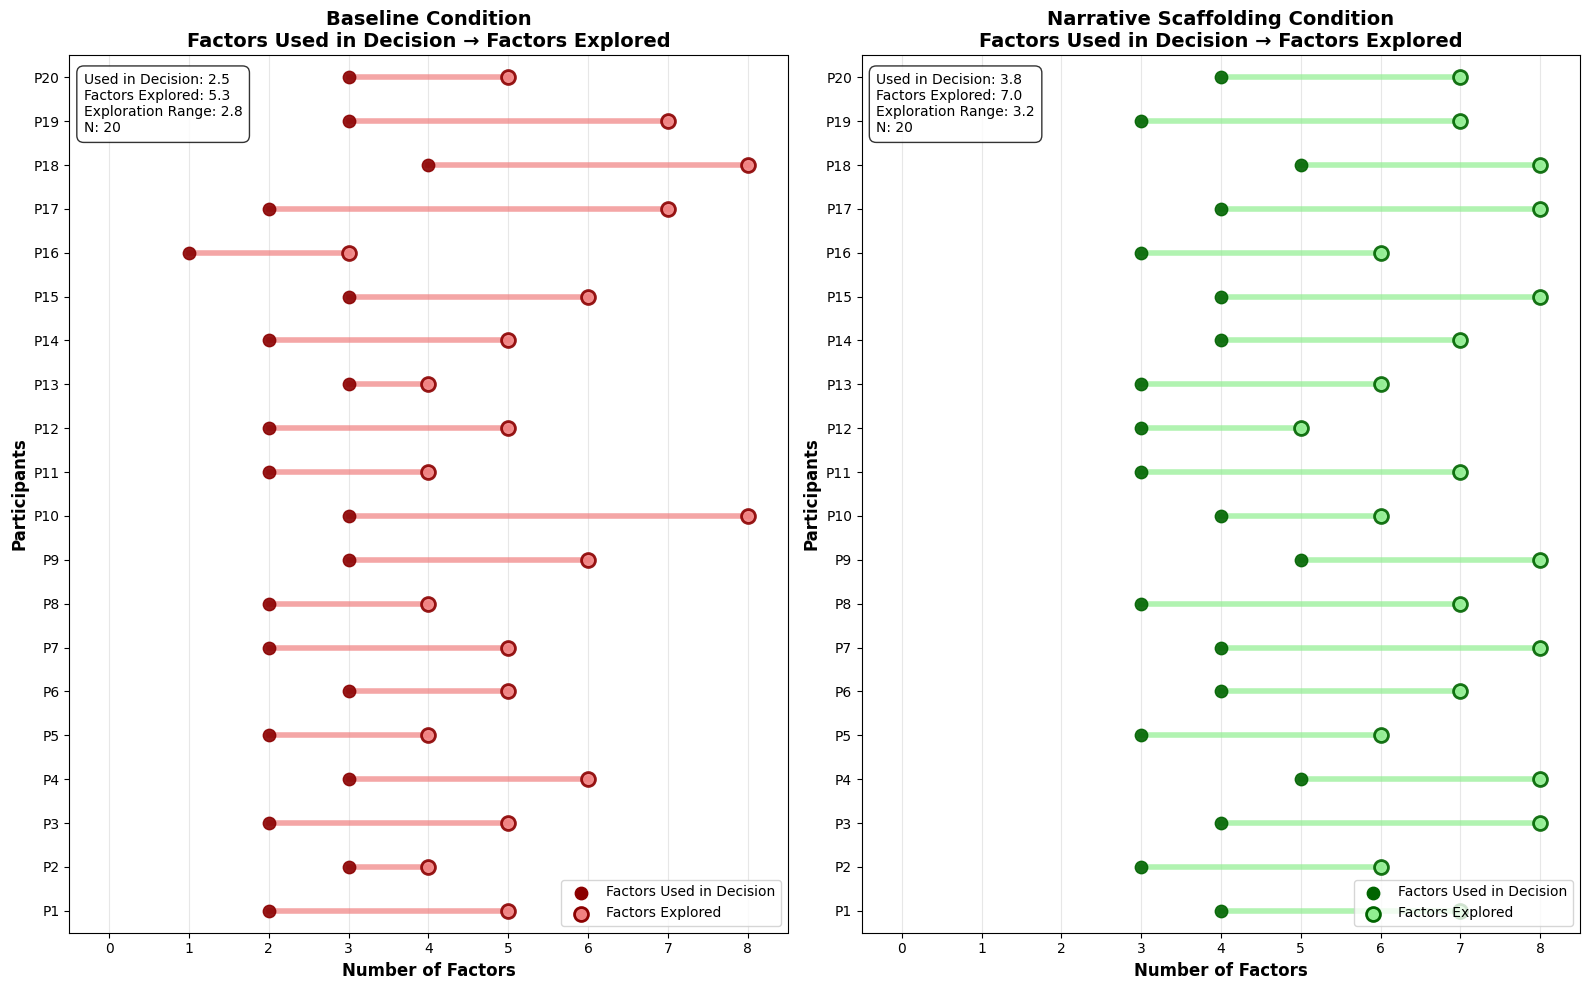


=== DUMBBELL PLOT DATA BREAKDOWN ===

Baseline Condition (P1-P17):
  P1: 2 used → 5 explored (range: 3)
  P2: 3 used → 4 explored (range: 1)
  P3: 2 used → 5 explored (range: 3)
  P4: 3 used → 6 explored (range: 3)
  P5: 2 used → 4 explored (range: 2)
  P6: 3 used → 5 explored (range: 2)
  P7: 2 used → 5 explored (range: 3)
  P8: 2 used → 4 explored (range: 2)
  P9: 3 used → 6 explored (range: 3)
  P10: 3 used → 8 explored (range: 5)
  P11: 2 used → 4 explored (range: 2)
  P12: 2 used → 5 explored (range: 3)
  P13: 3 used → 4 explored (range: 1)
  P14: 2 used → 5 explored (range: 3)
  P15: 3 used → 6 explored (range: 3)
  P16: 1 used → 3 explored (range: 2)
  P17: 2 used → 7 explored (range: 5)
  P18: 4 used → 8 explored (range: 4)
  P19: 3 used → 7 explored (range: 4)
  P20: 3 used → 5 explored (range: 2)

Narrative Scaffolding Condition (P1-P17):
  P1: 4 used → 7 explored (range: 3)
  P2: 3 used → 6 explored (range: 3)
  P3: 4 used → 8 explored (range: 4)
  P4: 5 used → 8 explored (

In [33]:
# Create dumbbell plots showing range from factors_used_in_decision to factors_explored
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

# Prepare data
baseline_data = participant_summary[participant_summary['condition'] == 'Baseline'].copy()
ns_data = participant_summary[participant_summary['condition'] == 'NS'].copy()

# Create data with participant numbers P1-P17 (keep original order, don't sort)
baseline_start = baseline_data['factors_used_in_decision'].fillna(0)
baseline_end = baseline_data['factors_explored']
ns_start = ns_data['factors_used_in_decision'].fillna(0) 
ns_end = ns_data['factors_explored']

# Create combined data WITHOUT sorting to maintain P1-P17 order
baseline_combined = pd.DataFrame({
    'start': baseline_start,
    'end': baseline_end,
    'participant_id': baseline_data['participant_id']
}).reset_index(drop=True)

ns_combined = pd.DataFrame({
    'start': ns_start,
    'end': ns_end,
    'participant_id': ns_data['participant_id']
}).reset_index(drop=True)

# Create participant indices (y-axis positions) - P1 to P17
baseline_y = range(len(baseline_combined))
ns_y = range(len(ns_combined))

# Colors for the plots
baseline_color = 'lightcoral'
ns_color = 'lightgreen'

# Plot Baseline dumbbell
for i, (_, row) in enumerate(baseline_combined.iterrows()):
    start_val = row['start']
    end_val = row['end']
    
    # Draw line from start to end
    ax1.plot([start_val, end_val], [i, i], color=baseline_color, linewidth=4, alpha=0.7, zorder=2)
    
    # Draw start point (factors_used_in_decision)
    ax1.scatter(start_val, i, color='darkred', s=80, alpha=0.9, zorder=3, marker='o')
    
    # Draw end point (factors_explored)
    ax1.scatter(end_val, i, color=baseline_color, s=100, alpha=0.9, zorder=3, 
               edgecolors='darkred', linewidth=2, marker='o')

ax1.set_xlim(-0.5, 8.5)
ax1.set_ylim(-0.5, len(baseline_combined) - 0.5)
ax1.set_xlabel('Number of Factors', fontweight='bold', fontsize=12)
ax1.set_ylabel('Participants', fontweight='bold', fontsize=12)
ax1.set_title('Baseline Condition\nFactors Used in Decision → Factors Explored', fontweight='bold', fontsize=14)
ax1.grid(True, alpha=0.3, axis='x')
ax1.set_xticks(range(0, 9))

# Set y-axis to show P1, P2, P3, etc.
ax1.set_yticks(range(len(baseline_combined)))
ax1.set_yticklabels([f'P{i+1}' for i in range(len(baseline_combined))])

# Add legend for baseline
ax1.scatter([], [], color='darkred', s=80, label='Factors Used in Decision', marker='o')
ax1.scatter([], [], color=baseline_color, s=100, edgecolors='darkred', linewidth=2, 
           label='Factors Explored', marker='o')
ax1.legend(loc='lower right', fontsize=10)

# Add statistics text for baseline
baseline_start_mean = baseline_combined['start'].mean()
baseline_end_mean = baseline_combined['end'].mean()
baseline_range_mean = baseline_end_mean - baseline_start_mean
stats_text = f'Used in Decision: {baseline_start_mean:.1f}\nFactors Explored: {baseline_end_mean:.1f}\nExploration Range: {baseline_range_mean:.1f}\nN: {len(baseline_combined)}'
ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes, fontsize=10, 
         verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

# Plot Narrative Scaffolding dumbbell
for i, (_, row) in enumerate(ns_combined.iterrows()):
    start_val = row['start']
    end_val = row['end']
    
    # Draw line from start to end
    ax2.plot([start_val, end_val], [i, i], color=ns_color, linewidth=4, alpha=0.7, zorder=2)
    
    # Draw start point (factors_used_in_decision)
    ax2.scatter(start_val, i, color='darkgreen', s=80, alpha=0.9, zorder=3, marker='o')
    
    # Draw end point (factors_explored)
    ax2.scatter(end_val, i, color=ns_color, s=100, alpha=0.9, zorder=3, 
               edgecolors='darkgreen', linewidth=2, marker='o')

ax2.set_xlim(-0.5, 8.5)
ax2.set_ylim(-0.5, len(ns_combined) - 0.5)
ax2.set_xlabel('Number of Factors', fontweight='bold', fontsize=12)
ax2.set_ylabel('Participants', fontweight='bold', fontsize=12)
ax2.set_title('Narrative Scaffolding Condition\nFactors Used in Decision → Factors Explored', fontweight='bold', fontsize=14)
ax2.grid(True, alpha=0.3, axis='x')
ax2.set_xticks(range(0, 9))

# Set y-axis to show P1, P2, P3, etc.
ax2.set_yticks(range(len(ns_combined)))
ax2.set_yticklabels([f'P{i+1}' for i in range(len(ns_combined))])

# Add legend for NS
ax2.scatter([], [], color='darkgreen', s=80, label='Factors Used in Decision', marker='o')
ax2.scatter([], [], color=ns_color, s=100, edgecolors='darkgreen', linewidth=2, 
           label='Factors Explored', marker='o')
ax2.legend(loc='lower right', fontsize=10)

# Add statistics text for NS
ns_start_mean = ns_combined['start'].mean()
ns_end_mean = ns_combined['end'].mean()
ns_range_mean = ns_end_mean - ns_start_mean
stats_text = f'Used in Decision: {ns_start_mean:.1f}\nFactors Explored: {ns_end_mean:.1f}\nExploration Range: {ns_range_mean:.1f}\nN: {len(ns_combined)}'
ax2.text(0.02, 0.98, stats_text, transform=ax2.transAxes, fontsize=10, 
         verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Print detailed breakdown
print("\n=== DUMBBELL PLOT DATA BREAKDOWN ===")
print(f"\nBaseline Condition (P1-P17):")
for i, (_, row) in enumerate(baseline_combined.iterrows()):
    print(f"  P{i+1}: {row['start']:.0f} used → {row['end']:.0f} explored (range: {row['end']-row['start']:.0f})")

print(f"\nNarrative Scaffolding Condition (P1-P17):")
for i, (_, row) in enumerate(ns_combined.iterrows()):
    print(f"  P{i+1}: {row['start']:.0f} used → {row['end']:.0f} explored (range: {row['end']-row['start']:.0f})")

print(f"\nSummary Statistics:")
print(f"Baseline - Average exploration range: {baseline_range_mean:.1f}")
print(f"NS - Average exploration range: {ns_range_mean:.1f}")
print(f"Difference in exploration range: {ns_range_mean - baseline_range_mean:+.1f}")

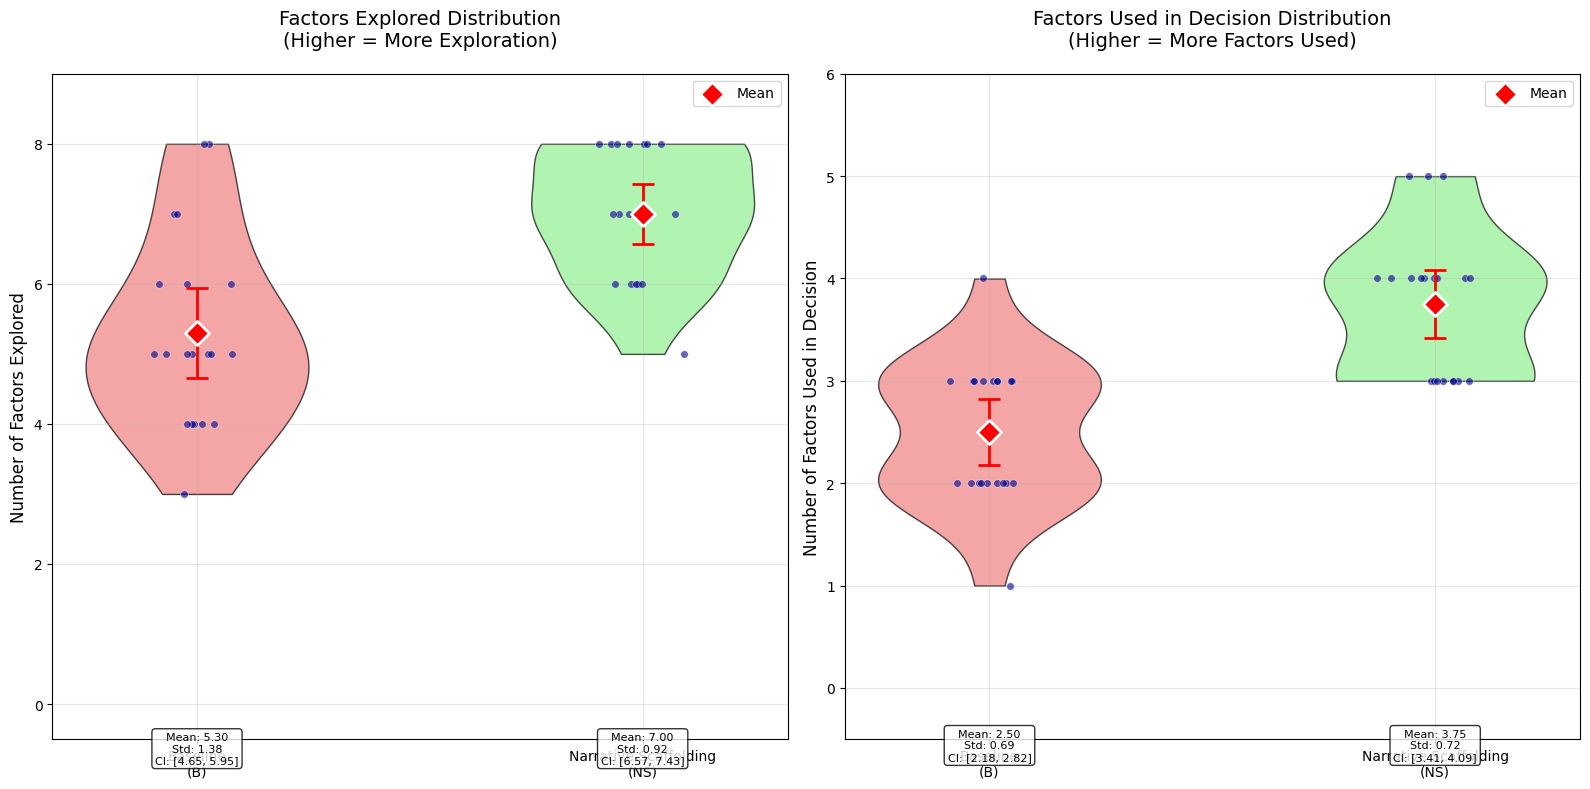


STATISTICAL TESTS FOR FACTOR METRICS

1. FACTORS EXPLORED (Baseline vs Narrative Scaffolding)
-------------------------------------------------------
Baseline - Mean: 5.30, Std: 1.38, N: 20
NS - Mean: 7.00, Std: 0.92, N: 20

Welch's t-test:
  t-statistic: -4.5868
  p-value: 0.000062
  Significant (α=0.05): Yes

Mann-Whitney U test:
  U-statistic: 66.000
  p-value: 0.000228
  Significant (α=0.05): Yes

Effect size (Cohen's d): 1.450
Interpretation: large effect


2. FACTORS USED IN DECISION (Baseline vs Narrative Scaffolding)
------------------------------------------------------------
Baseline - Mean: 2.50, Std: 0.69, N: 20
NS - Mean: 3.75, Std: 0.72, N: 20

Welch's t-test:
  t-statistic: -5.6273
  p-value: 0.000002
  Significant (α=0.05): Yes

Mann-Whitney U test:
  U-statistic: 48.500
  p-value: 0.000016
  Significant (α=0.05): Yes

Effect size (Cohen's d): 1.780
Interpretation: large effect

VIOLIN PLOT ANALYSIS SUMMARY WITH STATISTICAL RESULTS

📊 FACTORS EXPLORED:
   • Baseline Di

In [34]:
# Create violin plots for factor metrics comparison (NS vs Baseline)
# Matching the exact style from analysis.ipynb
from scipy import stats

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Prepare data for violin plots
baseline_data = participant_summary[participant_summary['condition'] == 'Baseline']
ns_data = participant_summary[participant_summary['condition'] == 'NS']

# Violin plot for Factors Explored
factors_explored_baseline = baseline_data['factors_explored'].dropna()
factors_explored_ns = ns_data['factors_explored'].dropna()
factors_explored_data = [factors_explored_baseline, factors_explored_ns]
positions = [1, 2]

# Create violin plot 1
violin1 = ax1.violinplot(factors_explored_data, positions=positions, showmeans=False, showmedians=False, showextrema=False)

# Customize violin colors (matching analysis.ipynb style)
colors = ['lightcoral', 'lightgreen']
for pc, color in zip(violin1['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(1)

# Add individual data points with jitter (matching analysis.ipynb)
np.random.seed(42)  # For reproducible jitter
for j, (dataset, pos) in enumerate(zip(factors_explored_data, positions)):
    # Add small random jitter to x-coordinates
    x_jitter = np.random.normal(pos, 0.05, size=len(dataset))
    ax1.scatter(x_jitter, dataset, alpha=0.6, s=30, color='darkblue', edgecolors='white', linewidth=0.5, zorder=5)

# Calculate means and confidence intervals
baseline_mean_exp = factors_explored_baseline.mean()
baseline_std_exp = factors_explored_baseline.std()
ns_mean_exp = factors_explored_ns.mean()
ns_std_exp = factors_explored_ns.std()

# 95% confidence intervals
baseline_ci_exp = stats.t.interval(0.95, len(factors_explored_baseline)-1, loc=baseline_mean_exp, scale=stats.sem(factors_explored_baseline))
ns_ci_exp = stats.t.interval(0.95, len(factors_explored_ns)-1, loc=ns_mean_exp, scale=stats.sem(factors_explored_ns))

# Add mean markers (red diamonds with white edges)
ax1.scatter([1], [baseline_mean_exp], color='red', s=150, marker='D', label='Mean', zorder=10, edgecolors='white', linewidth=2)
ax1.scatter([2], [ns_mean_exp], color='red', s=150, marker='D', zorder=10, edgecolors='white', linewidth=2)

# Add confidence interval error bars
ax1.errorbar([1], [baseline_mean_exp], yerr=[[baseline_mean_exp - baseline_ci_exp[0]], [baseline_ci_exp[1] - baseline_mean_exp]], 
            color='red', capsize=8, capthick=2, linewidth=2, zorder=8)
ax1.errorbar([2], [ns_mean_exp], yerr=[[ns_mean_exp - ns_ci_exp[0]], [ns_ci_exp[1] - ns_mean_exp]], 
            color='red', capsize=8, capthick=2, linewidth=2, zorder=8)

# Customize plot 1
ax1.set_xticks([1, 2])
ax1.set_xticklabels(['Baseline\n(B)', 'Narrative Scaffolding\n(NS)'])
ax1.set_ylabel('Number of Factors Explored', fontsize=12)
ax1.set_title('Factors Explored Distribution\n(Higher = More Exploration)', fontsize=14, pad=20)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.5, max(max(factors_explored_baseline), max(factors_explored_ns)) + 1)

# Add text annotations for means, std, and CIs
ax1.text(1, -0.4, f'Mean: {baseline_mean_exp:.2f}\nStd: {baseline_std_exp:.2f}\nCI: [{baseline_ci_exp[0]:.2f}, {baseline_ci_exp[1]:.2f}]', 
         ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax1.text(2, -0.4, f'Mean: {ns_mean_exp:.2f}\nStd: {ns_std_exp:.2f}\nCI: [{ns_ci_exp[0]:.2f}, {ns_ci_exp[1]:.2f}]', 
         ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax1.legend(loc='upper right')

# Violin plot for Factors Used in Decision
factors_used_baseline = baseline_data['factors_used_in_decision'].dropna()
factors_used_ns = ns_data['factors_used_in_decision'].dropna()
factors_used_data = [factors_used_baseline, factors_used_ns]

# Create violin plot 2
violin2 = ax2.violinplot(factors_used_data, positions=positions, showmeans=False, showmedians=False, showextrema=False)

# Customize violin colors (matching analysis.ipynb style)
for pc, color in zip(violin2['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(1)

# Add individual data points with jitter (matching analysis.ipynb)
for j, (dataset, pos) in enumerate(zip(factors_used_data, positions)):
    # Add small random jitter to x-coordinates
    x_jitter = np.random.normal(pos, 0.05, size=len(dataset))
    ax2.scatter(x_jitter, dataset, alpha=0.6, s=30, color='darkblue', edgecolors='white', linewidth=0.5, zorder=5)

# Calculate means and confidence intervals
baseline_mean_used = factors_used_baseline.mean()
baseline_std_used = factors_used_baseline.std()
ns_mean_used = factors_used_ns.mean()
ns_std_used = factors_used_ns.std()

# 95% confidence intervals
baseline_ci_used = stats.t.interval(0.95, len(factors_used_baseline)-1, loc=baseline_mean_used, scale=stats.sem(factors_used_baseline))
ns_ci_used = stats.t.interval(0.95, len(factors_used_ns)-1, loc=ns_mean_used, scale=stats.sem(factors_used_ns))

# Add mean markers (red diamonds with white edges)
ax2.scatter([1], [baseline_mean_used], color='red', s=150, marker='D', label='Mean', zorder=10, edgecolors='white', linewidth=2)
ax2.scatter([2], [ns_mean_used], color='red', s=150, marker='D', zorder=10, edgecolors='white', linewidth=2)

# Add confidence interval error bars
ax2.errorbar([1], [baseline_mean_used], yerr=[[baseline_mean_used - baseline_ci_used[0]], [baseline_ci_used[1] - baseline_mean_used]], 
            color='red', capsize=8, capthick=2, linewidth=2, zorder=8)
ax2.errorbar([2], [ns_mean_used], yerr=[[ns_mean_used - ns_ci_used[0]], [ns_ci_used[1] - ns_mean_used]], 
            color='red', capsize=8, capthick=2, linewidth=2, zorder=8)

# Customize plot 2
ax2.set_xticks([1, 2])
ax2.set_xticklabels(['Baseline\n(B)', 'Narrative Scaffolding\n(NS)'])
ax2.set_ylabel('Number of Factors Used in Decision', fontsize=12)
ax2.set_title('Factors Used in Decision Distribution\n(Higher = More Factors Used)', fontsize=14, pad=20)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.5, max(max(factors_used_baseline), max(factors_used_ns)) + 1)

# Add text annotations for means, std, and CIs
ax2.text(1, -0.4, f'Mean: {baseline_mean_used:.2f}\nStd: {baseline_std_used:.2f}\nCI: [{baseline_ci_used[0]:.2f}, {baseline_ci_used[1]:.2f}]', 
         ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax2.text(2, -0.4, f'Mean: {ns_mean_used:.2f}\nStd: {ns_std_used:.2f}\nCI: [{ns_ci_used[0]:.2f}, {ns_ci_used[1]:.2f}]', 
         ha='center', va='top', fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Statistical Tests for Violin Plot Data
print("\n" + "="*80)
print("STATISTICAL TESTS FOR FACTOR METRICS")
print("="*80)

# Test 1: Factors Explored
print("\n1. FACTORS EXPLORED (Baseline vs Narrative Scaffolding)")
print("-" * 55)

# Print descriptive statistics including std
print(f"Baseline - Mean: {baseline_mean_exp:.2f}, Std: {baseline_std_exp:.2f}, N: {len(factors_explored_baseline)}")
print(f"NS - Mean: {ns_mean_exp:.2f}, Std: {ns_std_exp:.2f}, N: {len(factors_explored_ns)}")

# Paired t-test (since same participants used both conditions)
try:
    t_stat_exp, p_value_exp = stats.ttest_ind(factors_explored_baseline, factors_explored_ns, equal_var=False)
    
    # Mann-Whitney U test (non-parametric)
    u_stat_exp, u_p_value_exp = stats.mannwhitneyu(factors_explored_baseline, factors_explored_ns, alternative='two-sided')
    
    # Effect size (Cohen's d)
    pooled_std_exp = np.sqrt(((len(factors_explored_baseline)-1)*factors_explored_baseline.std()**2 + 
                             (len(factors_explored_ns)-1)*factors_explored_ns.std()**2) / 
                            (len(factors_explored_baseline)+len(factors_explored_ns)-2))
    cohen_d_exp = (ns_mean_exp - baseline_mean_exp) / pooled_std_exp
    
    print(f"\nWelch's t-test:")
    print(f"  t-statistic: {t_stat_exp:.4f}")
    print(f"  p-value: {p_value_exp:.6f}")
    print(f"  Significant (α=0.05): {'Yes' if p_value_exp < 0.05 else 'No'}")
    
    print(f"\nMann-Whitney U test:")
    print(f"  U-statistic: {u_stat_exp:.3f}")
    print(f"  p-value: {u_p_value_exp:.6f}")
    print(f"  Significant (α=0.05): {'Yes' if u_p_value_exp < 0.05 else 'No'}")
    
    print(f"\nEffect size (Cohen's d): {cohen_d_exp:.3f}")
    
    # Interpret effect size
    if abs(cohen_d_exp) < 0.2:
        effect_label_exp = "negligible"
    elif abs(cohen_d_exp) < 0.5:
        effect_label_exp = "small"
    elif abs(cohen_d_exp) < 0.8:
        effect_label_exp = "medium"
    else:
        effect_label_exp = "large"
    
    print(f"Interpretation: {effect_label_exp} effect")
    
except Exception as e:
    print(f"Error in statistical tests: {e}")

# Test 2: Factors Used in Decision
print("\n\n2. FACTORS USED IN DECISION (Baseline vs Narrative Scaffolding)")
print("-" * 60)

# Print descriptive statistics including std
print(f"Baseline - Mean: {baseline_mean_used:.2f}, Std: {baseline_std_used:.2f}, N: {len(factors_used_baseline)}")
print(f"NS - Mean: {ns_mean_used:.2f}, Std: {ns_std_used:.2f}, N: {len(factors_used_ns)}")

try:
    t_stat_used, p_value_used = stats.ttest_ind(factors_used_baseline, factors_used_ns, equal_var=False)
    
    # Mann-Whitney U test (non-parametric)
    u_stat_used, u_p_value_used = stats.mannwhitneyu(factors_used_baseline, factors_used_ns, alternative='two-sided')
    
    # Effect size (Cohen's d)
    pooled_std_used = np.sqrt(((len(factors_used_baseline)-1)*factors_used_baseline.std()**2 + 
                              (len(factors_used_ns)-1)*factors_used_ns.std()**2) / 
                             (len(factors_used_baseline)+len(factors_used_ns)-2))
    cohen_d_used = (ns_mean_used - baseline_mean_used) / pooled_std_used
    
    print(f"\nWelch's t-test:")
    print(f"  t-statistic: {t_stat_used:.4f}")
    print(f"  p-value: {p_value_used:.6f}")
    print(f"  Significant (α=0.05): {'Yes' if p_value_used < 0.05 else 'No'}")
    
    print(f"\nMann-Whitney U test:")
    print(f"  U-statistic: {u_stat_used:.3f}")
    print(f"  p-value: {u_p_value_used:.6f}")
    print(f"  Significant (α=0.05): {'Yes' if u_p_value_used < 0.05 else 'No'}")
    
    print(f"\nEffect size (Cohen's d): {cohen_d_used:.3f}")
    
    # Interpret effect size
    if abs(cohen_d_used) < 0.2:
        effect_label_used = "negligible"
    elif abs(cohen_d_used) < 0.5:
        effect_label_used = "small"
    elif abs(cohen_d_used) < 0.8:
        effect_label_used = "medium"
    else:
        effect_label_used = "large"
    
    print(f"Interpretation: {effect_label_used} effect")
    
except Exception as e:
    print(f"Error in statistical tests: {e}")

# Print violin plot summary with statistical results
print("\n" + "="*80)
print("VIOLIN PLOT ANALYSIS SUMMARY WITH STATISTICAL RESULTS")
print("="*80)

# Calculate improvement ratios
ratio_exp = ns_mean_exp / baseline_mean_exp if baseline_mean_exp > 0 else float('inf')
ratio_used = ns_mean_used / baseline_mean_used if baseline_mean_used > 0 else float('inf')

print(f"\n📊 FACTORS EXPLORED:")
print(f"   • Baseline Distribution: Mean={baseline_mean_exp:.1f}, Std={baseline_std_exp:.1f}, N={len(factors_explored_baseline)}")
print(f"   • NS Distribution: Mean={ns_mean_exp:.1f}, Std={ns_std_exp:.1f}, N={len(factors_explored_ns)}")
print(f"   • Improvement: {ratio_exp:.2f}x ({((ratio_exp-1)*100):+.1f}%)")
if 'p_value_exp' in locals():
    significance_exp = "***" if p_value_exp < 0.001 else "**" if p_value_exp < 0.01 else "*" if p_value_exp < 0.05 else "ns"
    print(f"   • Statistical significance: p = {p_value_exp:.4f} {significance_exp}")
    print(f"   • Effect size: {effect_label_exp} (Cohen's d = {cohen_d_exp:.3f})")

print(f"\n🎯 FACTORS USED IN DECISION:")
print(f"   • Baseline Distribution: Mean={baseline_mean_used:.1f}, Std={baseline_std_used:.1f}, N={len(factors_used_baseline)}")
print(f"   • NS Distribution: Mean={ns_mean_used:.1f}, Std={ns_std_used:.1f}, N={len(factors_used_ns)}")
print(f"   • Improvement: {ratio_used:.2f}x ({((ratio_used-1)*100):+.1f}%)")
if 'p_value_used' in locals():
    significance_used = "***" if p_value_used < 0.001 else "**" if p_value_used < 0.01 else "*" if p_value_used < 0.05 else "ns"
    print(f"   • Statistical significance: p = {p_value_used:.4f} {significance_used}")
    print(f"   • Effect size: {effect_label_used} (Cohen's d = {cohen_d_used:.3f})")

print(f"\n🔍 VIOLIN PLOT INSIGHTS:")
print(f"   • The violin plots show the probability density of factor usage across conditions")
print(f"   • Wider sections indicate more participants had those values")
print(f"   • Individual data points are overlaid with jitter for clarity")
print(f"   • Red diamond markers show means with 95% confidence intervals")
print(f"   • Statistical tests include both parametric (t-test) and non-parametric (Mann-Whitney U)")

print(f"\n📈 KEY FINDINGS:")
if 'p_value_exp' in locals() and 'p_value_used' in locals():
    print(f"   • Factors Explored: {'Significant' if p_value_exp < 0.05 else 'Non-significant'} difference (p = {p_value_exp:.4f})")
    print(f"   • Factors Used: {'Significant' if p_value_used < 0.05 else 'Non-significant'} difference (p = {p_value_used:.4f})")
    print(f"   • Narrative Scaffolding shows {'improved' if ratio_exp > 1 and ratio_used > 1 else 'mixed'} factor engagement patterns")

print(f"\n💡 INTERPRETATION:")
print(f"   • Higher values indicate more comprehensive factor exploration and utilization")
print(f"   • Significance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")
print(f"   • Effect sizes help interpret practical significance beyond statistical significance")
print(f"   • Standard deviations show variability within each condition")

In [35]:
# Time Analysis: Final Time and Time Efficiency per Insight
print("=" * 80)
print("TIME ANALYSIS: BASELINE VS Narrative Scaffolding")
print("=" * 80)

# Separate data by condition
baseline_data = participant_summary[participant_summary['condition'] == 'Baseline'].copy()
ns_data = participant_summary[participant_summary['condition'] == 'NS'].copy()

# Extract time and insight metrics
baseline_time = baseline_data['final_time'].dropna()
baseline_insights = baseline_data['insights_generated'].dropna()
ns_time = ns_data['final_time'].dropna()
ns_insights = ns_data['insights_generated'].dropna()

# Calculate time per insight (efficiency metric)
baseline_time_per_insight = baseline_time / baseline_insights
ns_time_per_insight = ns_time / ns_insights

print("\n" + "=" * 60)
print("FINAL TIME ANALYSIS")
print("=" * 60)

# Basic statistics for final time
baseline_time_stats = {
    'count': len(baseline_time),
    'mean': baseline_time.mean(),
    'std': baseline_time.std(),
    'median': baseline_time.median(),
    'min': baseline_time.min(),
    'max': baseline_time.max()
}

ns_time_stats = {
    'count': len(ns_time),
    'mean': ns_time.mean(),
    'std': ns_time.std(),
    'median': ns_time.median(),
    'min': ns_time.min(),
    'max': ns_time.max()
}

print(f"\nBASELINE TIME STATISTICS:")
print(f"  Count: {baseline_time_stats['count']}")
print(f"  Mean: {baseline_time_stats['mean']:.2f} minutes")
print(f"  Std: {baseline_time_stats['std']:.2f} minutes")
print(f"  Median: {baseline_time_stats['median']:.2f} minutes")
print(f"  Range: {baseline_time_stats['min']:.2f} - {baseline_time_stats['max']:.2f} minutes")

print(f"\nNarrative Scaffolding TIME STATISTICS:")
print(f"  Count: {ns_time_stats['count']}")
print(f"  Mean: {ns_time_stats['mean']:.2f} minutes")
print(f"  Std: {ns_time_stats['std']:.2f} minutes")
print(f"  Median: {ns_time_stats['median']:.2f} minutes")
print(f"  Range: {ns_time_stats['min']:.2f} - {ns_time_stats['max']:.2f} minutes")

# Calculate time comparison
time_ratio = ns_time_stats['mean'] / baseline_time_stats['mean'] if baseline_time_stats['mean'] > 0 else float('inf')
time_difference = ns_time_stats['mean'] - baseline_time_stats['mean']

print(f"\nTIME COMPARISON:")
print(f"  Mean Ratio (NS/Baseline): {time_ratio:.2f}x")
print(f"  Mean Difference (NS - Baseline): {time_difference:+.2f} minutes")
print(f"  Percentage Change: {((time_ratio - 1) * 100):+.1f}%")

# Statistical test for time
try:
    t_stat_time, p_val_time = stats.ttest_ind(baseline_time, ns_time, equal_var=False)
    print(f"  Statistical Test (Welch's t-test): t={t_stat_time:.3f}, p={p_val_time:.4f}")
    print(f"  Significant difference: {'Yes' if p_val_time < 0.05 else 'No'}")
except Exception as e:
    print(f"  Statistical test error: {e}")

print("\n" + "=" * 60)
print("TIME EFFICIENCY ANALYSIS (Time per Insight)")
print("=" * 60)

# Basic statistics for time per insight
baseline_efficiency_stats = {
    'count': len(baseline_time_per_insight),
    'mean': baseline_time_per_insight.mean(),
    'std': baseline_time_per_insight.std(),
    'median': baseline_time_per_insight.median(),
    'min': baseline_time_per_insight.min(),
    'max': baseline_time_per_insight.max()
}

ns_efficiency_stats = {
    'count': len(ns_time_per_insight),
    'mean': ns_time_per_insight.mean(),
    'std': ns_time_per_insight.std(),
    'median': ns_time_per_insight.median(),
    'min': ns_time_per_insight.min(),
    'max': ns_time_per_insight.max()
}

print(f"\nBASELINE TIME PER INSIGHT:")
print(f"  Count: {baseline_efficiency_stats['count']}")
print(f"  Mean: {baseline_efficiency_stats['mean']:.2f} minutes/insight")
print(f"  Std: {baseline_efficiency_stats['std']:.2f} minutes/insight")
print(f"  Median: {baseline_efficiency_stats['median']:.2f} minutes/insight")
print(f"  Range: {baseline_efficiency_stats['min']:.2f} - {baseline_efficiency_stats['max']:.2f} minutes/insight")

print(f"\nNarrative Scaffolding TIME PER INSIGHT:")
print(f"  Count: {ns_efficiency_stats['count']}")
print(f"  Mean: {ns_efficiency_stats['mean']:.2f} minutes/insight")
print(f"  Std: {ns_efficiency_stats['std']:.2f} minutes/insight")
print(f"  Median: {ns_efficiency_stats['median']:.2f} minutes/insight")
print(f"  Range: {ns_efficiency_stats['min']:.2f} - {ns_efficiency_stats['max']:.2f} minutes/insight")

# Calculate efficiency comparison
efficiency_ratio = ns_efficiency_stats['mean'] / baseline_efficiency_stats['mean'] if baseline_efficiency_stats['mean'] > 0 else float('inf')
efficiency_difference = ns_efficiency_stats['mean'] - baseline_efficiency_stats['mean']

print(f"\nEFFICIENCY COMPARISON:")
print(f"  Mean Ratio (NS/Baseline): {efficiency_ratio:.2f}x")
print(f"  Mean Difference (NS - Baseline): {efficiency_difference:+.2f} minutes/insight")
print(f"  Percentage Change: {((efficiency_ratio - 1) * 100):+.1f}%")

if efficiency_ratio < 1:
    print(f"  → Narrative Scaffolding is MORE efficient (less time per insight)")
else:
    print(f"  → Narrative Scaffolding is LESS efficient (more time per insight)")

# Statistical test for efficiency
try:
    t_stat_eff, p_val_eff = stats.ttest_ind(baseline_time_per_insight, ns_time_per_insight, equal_var=False)
    print(f"  Statistical Test (Welch's t-test): t={t_stat_eff:.3f}, p={p_val_eff:.4f}")
    print(f"  Significant difference: {'Yes' if p_val_eff < 0.05 else 'No'}")
except Exception as e:
    print(f"  Statistical test error: {e}")

print("\n" + "=" * 60)
print("INSIGHTS GENERATION COMPARISON")
print("=" * 60)

# Basic statistics for insights generated
baseline_insights_stats = {
    'count': len(baseline_insights),
    'mean': baseline_insights.mean(),
    'std': baseline_insights.std(),
    'median': baseline_insights.median(),
    'min': baseline_insights.min(),
    'max': baseline_insights.max(),
    'sum': baseline_insights.sum()
}

ns_insights_stats = {
    'count': len(ns_insights),
    'mean': ns_insights.mean(),
    'std': ns_insights.std(),
    'median': ns_insights.median(),
    'min': ns_insights.min(),
    'max': ns_insights.max(),
    'sum': ns_insights.sum()
}

print(f"\nBASELINE INSIGHTS GENERATED:")
print(f"  Count: {baseline_insights_stats['count']}")
print(f"  Mean: {baseline_insights_stats['mean']:.2f} insights")
print(f"  Std: {baseline_insights_stats['std']:.2f} insights")
print(f"  Total: {baseline_insights_stats['sum']:.0f} insights")

print(f"\nNarrative Scaffolding INSIGHTS GENERATED:")
print(f"  Count: {ns_insights_stats['count']}")
print(f"  Mean: {ns_insights_stats['mean']:.2f} insights")
print(f"  Std: {ns_insights_stats['std']:.2f} insights")
print(f"  Total: {ns_insights_stats['sum']:.0f} insights")

# Calculate insights comparison
insights_ratio = ns_insights_stats['mean'] / baseline_insights_stats['mean'] if baseline_insights_stats['mean'] > 0 else float('inf')
insights_difference = ns_insights_stats['mean'] - baseline_insights_stats['mean']

print(f"\nINSIGHTS COMPARISON:")
print(f"  Mean Ratio (NS/Baseline): {insights_ratio:.2f}x")
print(f"  Mean Difference (NS - Baseline): {insights_difference:+.2f} insights")
print(f"  Percentage Change: {((insights_ratio - 1) * 100):+.1f}%")

print("\n" + "=" * 80)
print("KEY SUMMARY")
print("=" * 80)

print(f"📊 TIME METRICS:")
print(f"   • Baseline: {baseline_time_stats['mean']:.1f} ± {baseline_time_stats['std']:.1f} minutes")
print(f"   • NS: {ns_time_stats['mean']:.1f} ± {ns_time_stats['std']:.1f} minutes")
print(f"   • Change: {((time_ratio - 1) * 100):+.1f}% ({time_ratio:.2f}x)")

print(f"\n⚡ EFFICIENCY METRICS (Time per Insight):")
print(f"   • Baseline: {baseline_efficiency_stats['mean']:.2f} ± {baseline_efficiency_stats['std']:.2f} min/insight")
print(f"   • NS: {ns_efficiency_stats['mean']:.2f} ± {ns_efficiency_stats['std']:.2f} min/insight")
print(f"   • Change: {((efficiency_ratio - 1) * 100):+.1f}% ({efficiency_ratio:.2f}x)")

print(f"\n💡 INSIGHTS METRICS:")
print(f"   • Baseline: {baseline_insights_stats['mean']:.1f} ± {baseline_insights_stats['std']:.1f} insights")
print(f"   • NS: {ns_insights_stats['mean']:.1f} ± {ns_insights_stats['std']:.1f} insights")
print(f"   • Change: {((insights_ratio - 1) * 100):+.1f}% ({insights_ratio:.2f}x)")

print(f"\n🎯 INTERPRETATION:")
if time_ratio > 1 and efficiency_ratio < 1:
    print(f"   • NS takes more total time BUT is more efficient per insight")
elif time_ratio > 1 and efficiency_ratio > 1:
    print(f"   • NS takes more total time AND is less efficient per insight")
elif time_ratio < 1 and efficiency_ratio < 1:
    print(f"   • NS takes less total time AND is more efficient per insight")
else:
    print(f"   • NS takes less total time BUT is less efficient per insight")

print(f"   • Trade-off between exploration depth and time efficiency")

TIME ANALYSIS: BASELINE VS Narrative Scaffolding

FINAL TIME ANALYSIS

BASELINE TIME STATISTICS:
  Count: 20
  Mean: 29.84 minutes
  Std: 0.87 minutes
  Median: 29.62 minutes
  Range: 28.65 - 31.54 minutes

Narrative Scaffolding TIME STATISTICS:
  Count: 20
  Mean: 31.59 minutes
  Std: 0.92 minutes
  Median: 31.47 minutes
  Range: 30.23 - 33.21 minutes

TIME COMPARISON:
  Mean Ratio (NS/Baseline): 1.06x
  Mean Difference (NS - Baseline): +1.75 minutes
  Percentage Change: +5.9%
  Statistical Test (Welch's t-test): t=-6.167, p=0.0000
  Significant difference: Yes

TIME EFFICIENCY ANALYSIS (Time per Insight)

BASELINE TIME PER INSIGHT:
  Count: 20
  Mean: 4.62 minutes/insight
  Std: 1.22 minutes/insight
  Median: 4.26 minutes/insight
  Range: 2.76 - 7.88 minutes/insight

Narrative Scaffolding TIME PER INSIGHT:
  Count: 20
  Mean: 2.31 minutes/insight
  Std: 0.76 minutes/insight
  Median: 2.47 minutes/insight
  Range: 0.92 - 3.37 minutes/insight

EFFICIENCY COMPARISON:
  Mean Ratio (NS/Ba